In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import cond, norm

## 1. Generate Ill-Conditioned, Noisy Dataset

To generate an ill-conditioned regression problem, we construct the design matrix X
using a controlled singular value decomposition:

    X = U S V^T

where U and V are random orthonormal matrices and S is a diagonal matrix containing
the singular values of X. The singular values are chosen to decay geometrically from
1 to 1/kappa, where kappa is the desired condition number. Since the condition number
of X is the ratio between its largest and smallest singular values, this construction
allows us to directly control ill-conditioning.

Ill-conditioning is important because the least-squares objective depends on X^T X.
The condition number of X^T X is approximately the square of the condition number of X.
Therefore, even moderately ill-conditioned data can produce a highly elongated loss
surface. This causes gradient descent to converge slowly, especially along directions
corresponding to small singular values.

After constructing X, the response vector is generated from the linear model

    y = X beta_true + epsilon

where beta_true is the true parameter vector and epsilon is Gaussian noise. By varying
both the condition number kappa and the noise standard deviation, we can study how
ill-conditioning and noisy observations affect the convergence and stability of
gradient-based optimization methods.

In [2]:
import numpy as np

# Generate a synthetic linear regression dataset with a controlled condition number.
'''
    model:
        y = X beta_true + noise

    The singular values of X are constructed so that:
        condition_number(X) = largest singular value / smallest singular value
'''
def generate_ill_conditioned_data(n_samples=500, n_features=2, condition_number=1e4, noise_std=0.1, random_state=42):
    rng = np.random.default_rng(random_state)

    # Random orthonormal matrices U and V
    A = rng.normal(size=(n_samples, n_features))
    U, _ = np.linalg.qr(A)

    B = rng.normal(size=(n_features, n_features))
    V, _ = np.linalg.qr(B)

    # Singular values decay from 1 to 1 / condition_number
    singular_values = np.geomspace(1, 1 / condition_number, n_features)

    # Construct X = U S V^T
    X = U @ np.diag(singular_values) @ V.T

    # True parameter vector
    beta_true = rng.normal(size=n_features)

    # Gaussian noise
    noise = rng.normal(loc=0.0, scale=noise_std, size=n_samples)

    # Response variable
    y = X @ beta_true + noise

    return X, y, beta_true, singular_values

In [3]:
condition_numbers = [10, 1e2, 1e4, 1e6] # Various levels of conditioning
noise_levels = [0.01, 0.1, 1.0] # Various levels of noise

datasets = {}

# Generate datasets for each noise level for every condition number
# In this case, we will end up with 12 datasets of varying conditioning and noise
for kappa in condition_numbers:
    for noise_std in noise_levels:
        X, y, beta_true, singular_values = generate_ill_conditioned_data(
            n_samples=500,
            n_features=20,
            condition_number=kappa,
            noise_std=noise_std,
            random_state=42
        )

        datasets[(kappa, noise_std)] = {
            "X": X,
            "y": y,
            "beta_true": beta_true,
            "singular_values": singular_values,
            "actual_condition_number": np.linalg.cond(X)
        }

        print(
            f"kappa target={kappa:.0e}, "
            f"noise={noise_std}, "
            f"actual cond(X)={np.linalg.cond(X):.2e}, "
            f"cond(X^T X)={np.linalg.cond(X.T @ X):.2e}"
        )

kappa target=1e+01, noise=0.01, actual cond(X)=1.00e+01, cond(X^T X)=1.00e+02
kappa target=1e+01, noise=0.1, actual cond(X)=1.00e+01, cond(X^T X)=1.00e+02
kappa target=1e+01, noise=1.0, actual cond(X)=1.00e+01, cond(X^T X)=1.00e+02
kappa target=1e+02, noise=0.01, actual cond(X)=1.00e+02, cond(X^T X)=1.00e+04
kappa target=1e+02, noise=0.1, actual cond(X)=1.00e+02, cond(X^T X)=1.00e+04
kappa target=1e+02, noise=1.0, actual cond(X)=1.00e+02, cond(X^T X)=1.00e+04
kappa target=1e+04, noise=0.01, actual cond(X)=1.00e+04, cond(X^T X)=1.00e+08
kappa target=1e+04, noise=0.1, actual cond(X)=1.00e+04, cond(X^T X)=1.00e+08
kappa target=1e+04, noise=1.0, actual cond(X)=1.00e+04, cond(X^T X)=1.00e+08
kappa target=1e+06, noise=0.01, actual cond(X)=1.00e+06, cond(X^T X)=1.00e+12
kappa target=1e+06, noise=0.1, actual cond(X)=1.00e+06, cond(X^T X)=1.00e+12
kappa target=1e+06, noise=1.0, actual cond(X)=1.00e+06, cond(X^T X)=1.00e+12


In [4]:
datasets[(10, 0.01)]["X"].shape, datasets[(10, 0.01)]["y"].shape

((500, 20), (500,))

## 2. Standard Gradient Descent

In [5]:
# Cost function: min_w 1/n||Xw - y||^2
# Gradient: (2/n)(X^T dot (Xw - y))

# --- Gradient Descent function
def gradient_descent(X, y, learning_rate, n_iterations=1000, random_state=None, beta_true=None):
    n_samples, n_features = X.shape

    # Initialize weights
    weights = np.zeros(n_features)

    # Store optimization history
    weight_history = [weights.copy()]
    loss_history = [np.mean((X @ weights - y) ** 2)]
    gradient_norm_history = []
    parameter_error_history = []

    if beta_true is not None:
        parameter_error_history.append(norm(weights - beta_true))

    for iteration in range(n_iterations):
        # Current predictions and errors
        predictions = X @ weights
        errors = predictions - y

        # Gradient of (1/n)||Xw - y||^2
        gradient = (2 / n_samples) * (X.T @ errors)

        # Store gradient norm
        gradient_norm_history.append(norm(gradient))

        # Gradient descent update
        weights = weights - learning_rate * gradient

        # Store updated weights
        weight_history.append(weights.copy())

        # Compute loss at updated weights
        updated_predictions = X @ weights
        updated_errors = updated_predictions - y
        loss_history.append(np.mean(updated_errors ** 2))

        if beta_true is not None:
            parameter_error_history.append(norm(weights - beta_true))

    return weights, weight_history, loss_history, gradient_norm_history, parameter_error_history

### Running Gradient Descent on All Datasets

Now we'll run the `gradient_descent` function on each of the 12 generated datasets. We'll use a fixed learning rate and a relatively high number of iterations to observe the convergence behavior, especially for the ill-conditioned cases.

We will store the `loss_history`, `gradient_norm_history`, and `parameter_error_history` for each run.

In [6]:
n_iterations = 20000 # CONFIG
learning_rate = 0.1 # CONFIG: A fixed learning rate to observe the effects of ill-conditioning

gd_results = {}

print(f"Running Gradient Descent for {n_iterations} iterations with learning rate {learning_rate}...")

for (kappa, noise_std), data in datasets.items():
    X = data["X"]
    y = data["y"]
    beta_true = data["beta_true"]

    weights_final, weight_history, loss_history, gradient_norm_history, parameter_error_history = gradient_descent(
        X, y, learning_rate=learning_rate, n_iterations=n_iterations, beta_true=beta_true
    )

    gd_results[(kappa, noise_std)] = {
        "weights_final": weights_final,
        "weight_history": weight_history, # Added this line to store the weight_history
        "loss_history": loss_history,
        "gradient_norm_history": gradient_norm_history,
        "parameter_error_history": parameter_error_history
    }

    print(
        f"Completed GD for kappa={kappa:.0e}, noise={noise_std}. "
        f"Final Loss: {loss_history[-1]:.4f}, Final Parameter Error: {parameter_error_history[-1]:.4f}"
    )

Running Gradient Descent for 20000 iterations with learning rate 0.1...
Completed GD for kappa=1e+01, noise=0.01. Final Loss: 0.0007, Final Parameter Error: 3.1717
Completed GD for kappa=1e+01, noise=0.1. Final Loss: 0.0099, Final Parameter Error: 3.3004
Completed GD for kappa=1e+01, noise=1.0. Final Loss: 0.9370, Final Parameter Error: 7.7784
Completed GD for kappa=1e+02, noise=0.01. Final Loss: 0.0004, Final Parameter Error: 4.2256
Completed GD for kappa=1e+02, noise=0.1. Final Loss: 0.0097, Final Parameter Error: 4.3158
Completed GD for kappa=1e+02, noise=1.0. Final Loss: 0.9467, Final Parameter Error: 7.7177
Completed GD for kappa=1e+04, noise=0.01. Final Loss: 0.0002, Final Parameter Error: 4.6280
Completed GD for kappa=1e+04, noise=0.1. Final Loss: 0.0097, Final Parameter Error: 4.6168
Completed GD for kappa=1e+04, noise=1.0. Final Loss: 0.9535, Final Parameter Error: 7.6350
Completed GD for kappa=1e+06, noise=0.01. Final Loss: 0.0003, Final Parameter Error: 4.7763
Completed GD f

### Visualizing Gradient Descent Convergence

Now we'll plot the optimization metrics (objective value, gradient norm, and parameter error) against the number of iterations. Each plot will be faceted by noise level, allowing us to compare the convergence behavior across different condition numbers.

**Interpreting Convergence Speed:**

*   **Objective Value & Parameter Error Plots**: A steeper descent and a lower final value indicate faster and better convergence. You will likely observe that for higher condition numbers, the curves flatten out at a higher objective value or parameter error, or descend much more slowly, demonstrating slower convergence or even divergence with a fixed learning rate.
*   **Gradient Norm Plot**: A faster decrease in gradient norm towards zero signifies that the optimizer is quickly finding a flatter region (i.e., closer to a minimum). Ill-conditioned problems often show the gradient norm decreasing very slowly or oscillating, indicating that the optimization struggles to make progress.

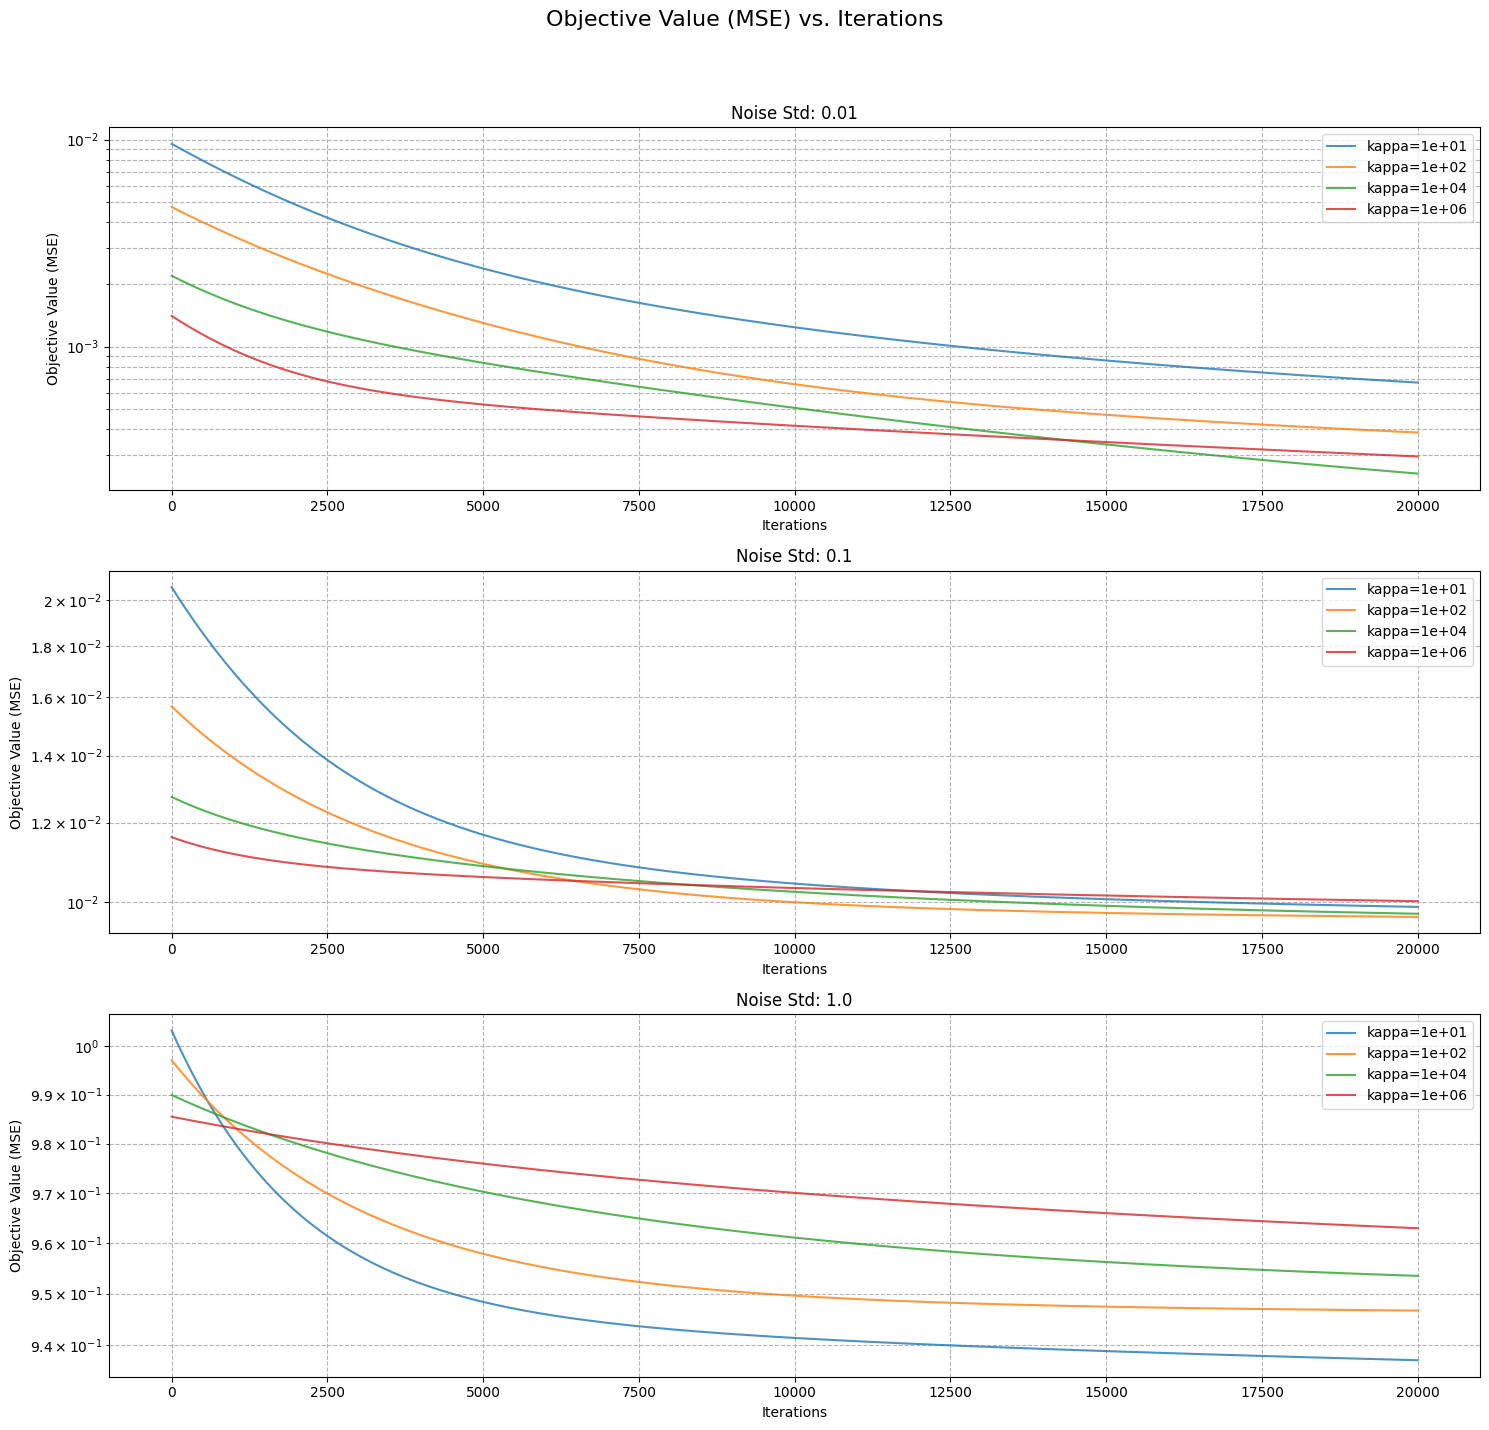

In [7]:
# Plot Objective Value vs Iterations
plt.figure(figsize=(15, 5 * len(noise_levels)))
plt.suptitle('Objective Value (MSE) vs. Iterations', fontsize=16)

for i, noise_std in enumerate(noise_levels):
    plt.subplot(len(noise_levels), 1, i + 1)
    for kappa in condition_numbers:
        key = (kappa, noise_std)
        if key in gd_results:
            history = gd_results[key]["loss_history"]
            plt.plot(history, label=f'kappa={kappa:.0e}', alpha=0.8)
    plt.title(f'Noise Std: {noise_std}')
    plt.xlabel('Iterations')
    plt.ylabel('Objective Value (MSE)')
    plt.yscale('log') # Use log scale for better visualization of decay
    plt.legend(loc='upper right')
    plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [8]:
# Plot Gradient Norm vs Iterations
'''plt.figure(figsize=(15, 5 * len(noise_levels)))
plt.suptitle('Gradient Norm vs. Iterations', fontsize=16)

for i, noise_std in enumerate(noise_levels):
    plt.subplot(len(noise_levels), 1, i + 1)
    for kappa in condition_numbers:
        key = (kappa, noise_std)
        if key in gd_results:
            # Gradient norm history is one element shorter than loss/param error
            # because it's calculated BEFORE the weight update for the current iteration.
            history = gd_results[key]["gradient_norm_history"]
            plt.plot(history, label=f'kappa={kappa:.0e}', alpha=0.8)
    plt.title(f'Noise Std: {noise_std}')
    plt.xlabel('Iterations')
    plt.ylabel('Gradient Norm')
    plt.yscale('log') # Use log scale for better visualization of decay
    plt.legend(loc='upper right')
    plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()'''

'plt.figure(figsize=(15, 5 * len(noise_levels)))\nplt.suptitle(\'Gradient Norm vs. Iterations\', fontsize=16)\n\nfor i, noise_std in enumerate(noise_levels):\n    plt.subplot(len(noise_levels), 1, i + 1)\n    for kappa in condition_numbers:\n        key = (kappa, noise_std)\n        if key in gd_results:\n            # Gradient norm history is one element shorter than loss/param error\n            # because it\'s calculated BEFORE the weight update for the current iteration.\n            history = gd_results[key]["gradient_norm_history"]\n            plt.plot(history, label=f\'kappa={kappa:.0e}\', alpha=0.8)\n    plt.title(f\'Noise Std: {noise_std}\')\n    plt.xlabel(\'Iterations\')\n    plt.ylabel(\'Gradient Norm\')\n    plt.yscale(\'log\') # Use log scale for better visualization of decay\n    plt.legend(loc=\'upper right\')\n    plt.grid(True, which="both", ls="--", c=\'0.7\')\nplt.tight_layout(rect=[0, 0.03, 1, 0.95])\nplt.show()'

In [9]:
# Plot Parameter Error vs Iterations
'''plt.figure(figsize=(15, 5 * len(noise_levels)))
plt.suptitle('Parameter Error (||w - w_true||) vs. Iterations', fontsize=16)

for i, noise_std in enumerate(noise_levels):
    plt.subplot(len(noise_levels), 1, i + 1)
    for kappa in condition_numbers:
        key = (kappa, noise_std)
        if key in gd_results:
            history = gd_results[key]["parameter_error_history"]
            plt.plot(history, label=f'kappa={kappa:.0e}', alpha=0.8)
    plt.title(f'Noise Std: {noise_std}')
    plt.xlabel('Iterations')
    plt.ylabel('Parameter Error')
    plt.yscale('log') # Use log scale for better visualization of decay
    plt.legend(loc='upper right')
    plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()'''

'plt.figure(figsize=(15, 5 * len(noise_levels)))\nplt.suptitle(\'Parameter Error (||w - w_true||) vs. Iterations\', fontsize=16)\n\nfor i, noise_std in enumerate(noise_levels):\n    plt.subplot(len(noise_levels), 1, i + 1)\n    for kappa in condition_numbers:\n        key = (kappa, noise_std)\n        if key in gd_results:\n            history = gd_results[key]["parameter_error_history"]\n            plt.plot(history, label=f\'kappa={kappa:.0e}\', alpha=0.8)\n    plt.title(f\'Noise Std: {noise_std}\')\n    plt.xlabel(\'Iterations\')\n    plt.ylabel(\'Parameter Error\')\n    plt.yscale(\'log\') # Use log scale for better visualization of decay\n    plt.legend(loc=\'upper right\')\n    plt.grid(True, which="both", ls="--", c=\'0.7\')\nplt.tight_layout(rect=[0, 0.03, 1, 0.95])\nplt.show()'

## 3. Ridge Regression

In [10]:
def ridge_closed_form_solution(X, y, lambda_val):
    n_samples, n_features = X.shape
    A = (X.T @ X) / n_samples + lambda_val * np.eye(n_features)
    b = (X.T @ y) / n_samples
    return np.linalg.solve(A, b)

In [11]:
# Cost function: min_w (1/n)||Xw - y||^2 + λ||w||^2,  λ > 0
# Gradient (2/n) X^T(Xw - y) + 2λw


# --- Gradient Descent function for ridge regression
def gradient_descent_ridge(X, y, learning_rate, lambda_val, n_iterations=1000):
    n_samples, n_features = X.shape

    weights = np.zeros(n_features)

    w_star = ridge_closed_form_solution(X, y, lambda_val)

    weight_history = [weights.copy()]
    loss_history = []
    distance_to_optimum = []

    for iteration in range(n_iterations + 1):
        predictions = X @ weights
        errors = predictions - y

        loss = np.mean(errors ** 2) + lambda_val * np.sum(weights ** 2)

        loss_history.append(loss)
        distance_to_optimum.append(np.linalg.norm(weights - w_star))

        if iteration == n_iterations:
            break

        gradient = (2 / n_samples) * (X.T @ errors) + 2 * lambda_val * weights
        weights = weights - learning_rate * gradient

        weight_history.append(weights.copy())

    return weights, weight_history, loss_history, distance_to_optimum

In [12]:
# Choose the learning rate using the largest eigenvalue of the Hessian
def ridge_lr(X, lambda_val):
  n_samples = X.shape[0]
  H = (2 / n_samples) * (X.T @ X) + 2 * lambda_val * np.eye(X.shape[1])
  L = np.linalg.eigvalsh(H).max()
  return 1 / L

In [13]:
# Various lambda vals
lambda_vals = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1]

for lambda_val in lambda_vals:
    #lr = ridge_lr(X, lambda_val)
    lr = 0.1

    weights, weight_history, loss_history, distance_history = gradient_descent_ridge(X, y, learning_rate=lr, lambda_val=lambda_val, n_iterations=1000)

    print(
        f"lambda={lambda_val:.0e}, "
        f"final loss={loss_history[-1]:.4e}, "
        f"distance to optimum={distance_history[-1]:.4e}"
    )

lambda=0e+00, final loss=9.8312e-01, distance to optimum=4.6827e+05
lambda=1e-04, final loss=9.8317e-01, distance to optimum=8.4835e+00
lambda=1e-03, final loss=9.8353e-01, distance to optimum=1.5409e+00
lambda=1e-02, final loss=9.8488e-01, distance to optimum=3.0896e-02
lambda=1e-01, final loss=9.8541e-01, distance to optimum=3.9434e-11
lambda=1e+00, final loss=9.8547e-01, distance to optimum=1.1774e-18


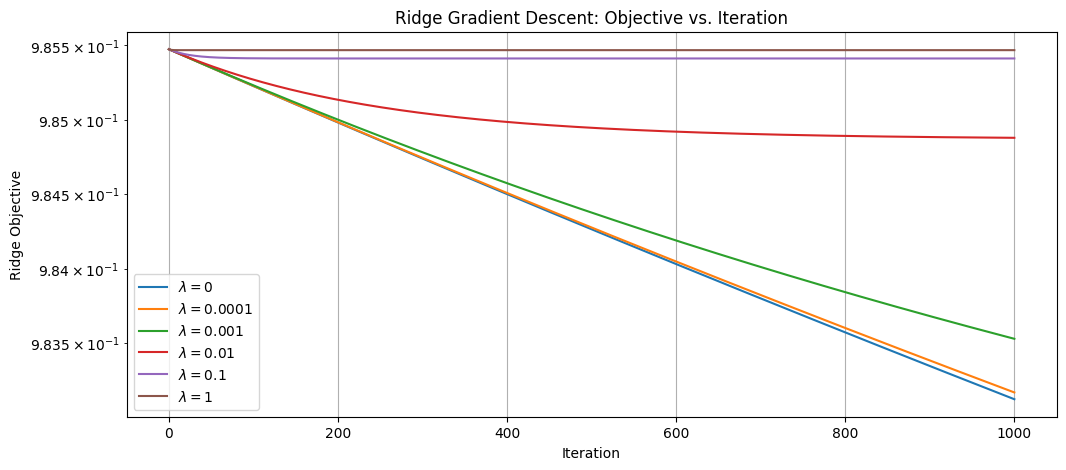

In [14]:
plt.figure(figsize=(12, 5))

for lambda_val in lambda_vals:
    weights, weight_history, loss_history, distance_history = gradient_descent_ridge(
        X, y,
        learning_rate=0.1,
        lambda_val=lambda_val,
        n_iterations=1000
    )

    plt.semilogy(loss_history, label=fr"$\lambda={lambda_val}$")

plt.xlabel("Iteration")
plt.ylabel("Ridge Objective")
plt.title("Ridge Gradient Descent: Objective vs. Iteration")
plt.legend()
plt.grid(True)
plt.show()

The distance-to-optimum plot clearly illustrates the effect of conditioning on convergence. Without regularization (λ = 0), gradient descent fails to converge due to extreme ill-conditioning. As λ increases, the condition number decreases significantly, leading to faster and more stable convergence. For sufficiently large λ, the problem becomes well-conditioned and gradient descent converges rapidly. However, large λ values introduce bias into the solution, highlighting the trade-off between optimization efficiency and solution accuracy.

There is a bias–conditioning tradeoff.

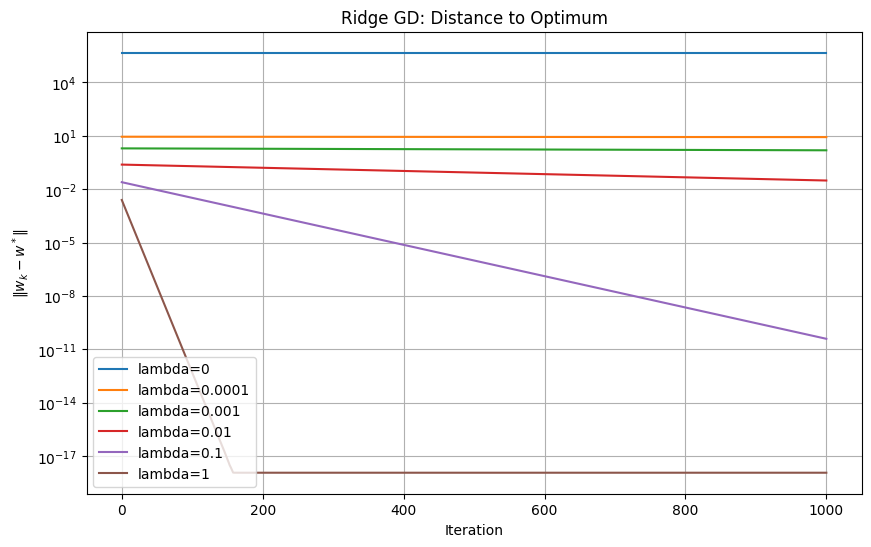

In [15]:
plt.figure(figsize=(10, 6))

for lambda_val in lambda_vals:
    weights, weight_history, loss_history, distance_history = gradient_descent_ridge(
        X, y,
        learning_rate=0.1,
        lambda_val=lambda_val,
        n_iterations=1000
    )

    plt.semilogy(distance_history, label=f"lambda={lambda_val}")

plt.xlabel("Iteration")
plt.ylabel(r"$\|w_k - w^*\|$")
plt.title("Ridge GD: Distance to Optimum")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Conditioning improvement
for lambda_val in lambda_vals:
    H = (X.T @ X) / X.shape[0] + lambda_val * np.eye(X.shape[1])
    print(f"lambda={lambda_val:.0e}, cond={np.linalg.cond(H):.2e}")

lambda=0e+00, cond=1.00e+12
lambda=1e-04, cond=2.10e+01
lambda=1e-03, cond=3.00e+00
lambda=1e-02, cond=1.20e+00
lambda=1e-01, cond=1.02e+00
lambda=1e+00, cond=1.00e+00


## 4. Mini-Batch SGD with Ridge

In [17]:
# --- Stochastic Gradient Descent function for ridge regression
def ridge_sgd(X, y, learning_rate, lambda_val, n_epochs=100, batch_size=32, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)

    loss_history = []
    weight_history = [weights.copy()] # Store initial weights

    for epoch in range(n_epochs):
        indices = rng.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            batch_size_actual = X_batch.shape[0]

            errors = X_batch @ weights - y_batch
            gradient = (
                (2 / batch_size_actual) * (X_batch.T @ errors)
                + 2 * lambda_val * weights
            )

            weights -= learning_rate * gradient
            weight_history.append(weights.copy()) # Store weights after each update

        # Store loss after each epoch
        full_errors = X @ weights - y
        loss = np.mean(full_errors ** 2) + lambda_val * np.sum(weights ** 2)
        loss_history.append(loss)

    return weights, weight_history, loss_history

## 5. Tradeoff Between GD and SGD Ridge

In [18]:
selected_kappa = 1e4
selected_noise_std = 0.1

# Retrieve the selected dataset
data = datasets[(selected_kappa, selected_noise_std)]
X = data["X"]
y = data["y"]
beta_true = data["beta_true"]

# Parameters for GD and SGD
lambda_val_comparison = 1e-3 # From previous good-performing lambda
learning_rate_comparison = 0.1 # Fixed learning rate
n_iterations_gd = 1000 # Number of iterations for GD
n_epochs_sgd = 1000 # Number of epochs for SGD
batch_size_sgd = 32 # Batch size for SGD

print(f"Comparing GD and SGD for kappa={selected_kappa:.0e}, noise={selected_noise_std}, lambda={lambda_val_comparison}")

# Run Gradient Descent (GD) Ridge
weights_gd, weight_history_gd, loss_history_gd, distance_gd = gradient_descent_ridge(
    X, y,
    learning_rate=learning_rate_comparison,
    lambda_val=lambda_val_comparison,
    n_iterations=n_iterations_gd
)

print(
    f"GD Final Loss: {loss_history_gd[-1]:.4e}, "
    f"GD Final Distance to Optimum: {distance_gd[-1]:.4e}"
)

# Run Stochastic Gradient Descent (SGD) Ridge
weights_sgd, _, _ = ridge_sgd(
    X, y,
    learning_rate=learning_rate_comparison,
    lambda_val=lambda_val_comparison,
    n_epochs=n_epochs_sgd,
    batch_size=batch_size_sgd
)

# For SGD, calculate distance to optimum for plotting
w_star_comparison = ridge_closed_form_solution(X, y, lambda_val_comparison)
distance_sgd = [np.linalg.norm(w - w_star_comparison) for w in weights_sgd]

weights_sgd_final, weight_history_sgd, loss_history_sgd = ridge_sgd(
    X, y,
    learning_rate=learning_rate_comparison,
    lambda_val=lambda_val_comparison,
    n_epochs=n_epochs_sgd,
    batch_size=batch_size_sgd
)

# Recompute distance_sgd using the full weight_history_sgd
distance_sgd = [np.linalg.norm(w - w_star_comparison) for w in weight_history_sgd]

print(
    f"SGD Final Loss: {loss_history_sgd[-1]:.4e}, "
    f"SGD Final Distance to Optimum: {distance_sgd[-1]:.4e}"
)


Comparing GD and SGD for kappa=1e+04, noise=0.1, lambda=0.001
GD Final Loss: 1.2158e-02, GD Final Distance to Optimum: 5.6300e-01
SGD Final Loss: 1.1658e-02, SGD Final Distance to Optimum: 9.7228e-03


### Comparing Objective Value

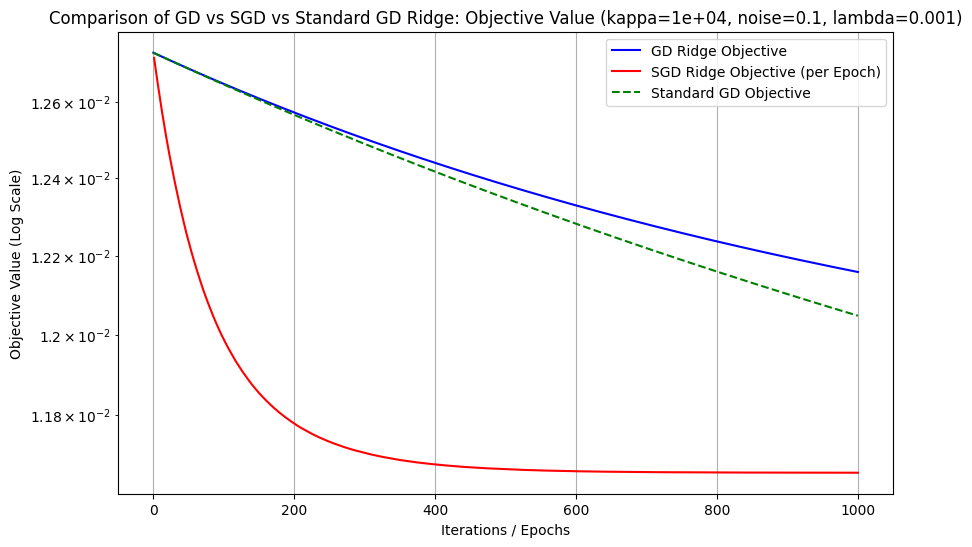

In [19]:
plt.figure(figsize=(10, 6))

# Plot GD Loss
plt.semilogy(loss_history_gd, label='GD Ridge Objective', color='blue')

# Plot SGD Loss
# For fair comparison, align SGD epochs with GD iterations (1 epoch = 1 iteration for x-axis)
plt.semilogy(np.arange(1, len(loss_history_sgd) + 1), loss_history_sgd, label='SGD Ridge Objective (per Epoch)', color='red')

# Add Standard GD Loss
standard_gd_loss = gd_results[(selected_kappa, selected_noise_std)]["loss_history"]
plt.semilogy(standard_gd_loss[:n_iterations_gd + 1], label='Standard GD Objective', color='green', linestyle='--') # Limit to n_iterations_gd for fair comparison

plt.xlabel('Iterations / Epochs')
plt.ylabel('Objective Value (Log Scale)')
plt.title(f'Comparison of GD vs SGD vs Standard GD Ridge: Objective Value (kappa={selected_kappa:.0e}, noise={selected_noise_std}, lambda={lambda_val_comparison})')
plt.legend()
plt.grid(True)
plt.show()

### Comparing Distance to Optimum

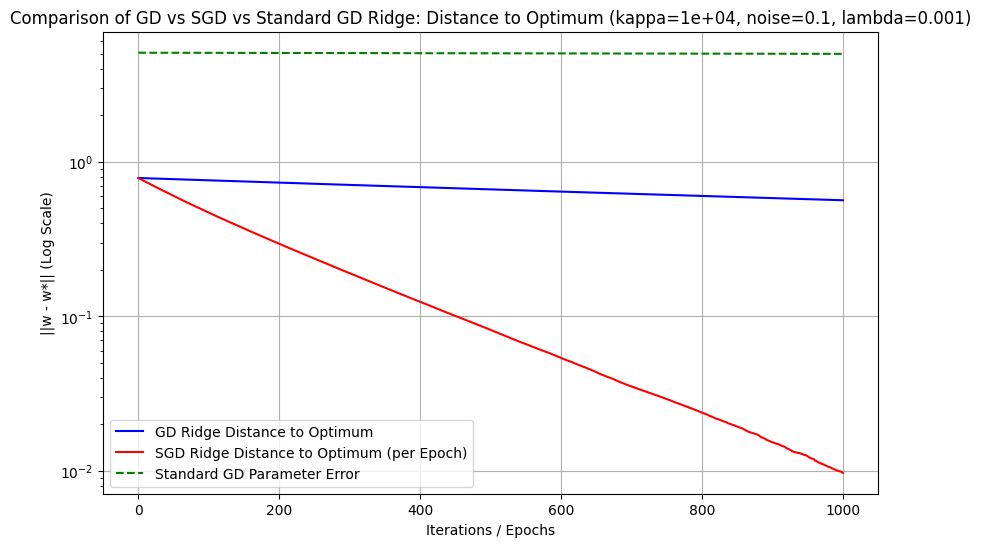

In [20]:
plt.figure(figsize=(10, 6))

# Plot GD Ridge Distance to Optimum
plt.semilogy(distance_gd, label='GD Ridge Distance to Optimum', color='blue')

# Plot SGD Ridge Distance to Optimum
updates_per_epoch = int(np.ceil(X.shape[0] / batch_size_sgd))
sgd_epochs_x_axis = np.arange(1, n_epochs_sgd + 1)
sgd_distances_at_epoch_end = [distance_sgd[i * updates_per_epoch] for i in sgd_epochs_x_axis]
plt.semilogy(sgd_epochs_x_axis, sgd_distances_at_epoch_end, label='SGD Ridge Distance to Optimum (per Epoch)', color='red')

# Add Standard GD Parameter Error (Distance to True Beta)
standard_gd_param_error = gd_results[(selected_kappa, selected_noise_std)]["parameter_error_history"]
plt.semilogy(standard_gd_param_error[:n_iterations_gd + 1], label='Standard GD Parameter Error', color='green', linestyle='--') # Limit to n_iterations_gd for fair comparison


plt.xlabel('Iterations / Epochs')
plt.ylabel('||w - w*|| (Log Scale)')
plt.title(f'Comparison of GD vs SGD vs Standard GD Ridge: Distance to Optimum (kappa={selected_kappa:.0e}, noise={selected_noise_std}, lambda={lambda_val_comparison})')
plt.legend()
plt.grid(True)
plt.show()

The comparison between standard gradient descent, ridge gradient descent, and stochastic gradient descent highlights the impact of conditioning on optimization. In the ill-conditioned setting, standard gradient descent fails to converge, remaining far from the optimal solution. Introducing ridge regularization significantly improves the conditioning of the problem, enabling gradient descent to converge. Furthermore, stochastic gradient descent achieves faster convergence in terms of epochs due to performing multiple parameter updates per pass through the data. These results demonstrate that both regularization and algorithm choice play critical roles in optimizing ill-conditioned problems.

## 5. Test on Real-World Dataset

In [21]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [22]:
from ucimlrepo import fetch_ucirepo
# DATASET: https://archive.ics.uci.edu/dataset/242/energy+efficiency

# fetch dataset
energy_efficiency = fetch_ucirepo(id=242)

# data (as pandas dataframes)
X = energy_efficiency.data.features
y = energy_efficiency.data.targets

# metadata
print(energy_efficiency.metadata)

# variable information
print(energy_efficiency.variables)

{'uci_id': 242, 'name': 'Energy Efficiency', 'repository_url': 'https://archive.ics.uci.edu/dataset/242/energy+efficiency', 'data_url': 'https://archive.ics.uci.edu/static/public/242/data.csv', 'abstract': 'This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 768, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y1', 'Y2'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C51307', 'creators': ['Athanasios Tsanas', 'Angeliki Xifara'], 'intro_paper': {'ID': 379, 'type': 'NATIVE', 'title': 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine 

In [23]:
# Turn the UCI dataset into a pandas dataframe

X.head()

,X1,X2,X3,X4,X5,X6,X7,X8
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [24]:
y.head()

,Y1,Y2
0,15.55,21.33
1,15.55,21.33
2,15.55,21.33
3,15.55,21.33
4,20.84,28.28


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert pandas objects to numpy
X_real = X.to_numpy()

# Choose one target: heating load
y_real = y.iloc[:, 0].to_numpy()   # Y1

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

# Standardize features
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# Center target
y_mean = y_train.mean()
y_train = y_train - y_mean
y_test = y_test - y_mean

In [26]:
# Check conditioning
print("cond(X_train):", np.linalg.cond(X_train))
print("cond(X^T X):", np.linalg.cond(X_train.T @ X_train))

cond(X_train): 3051362261656669.0
cond(X^T X): 2491212712314162.0


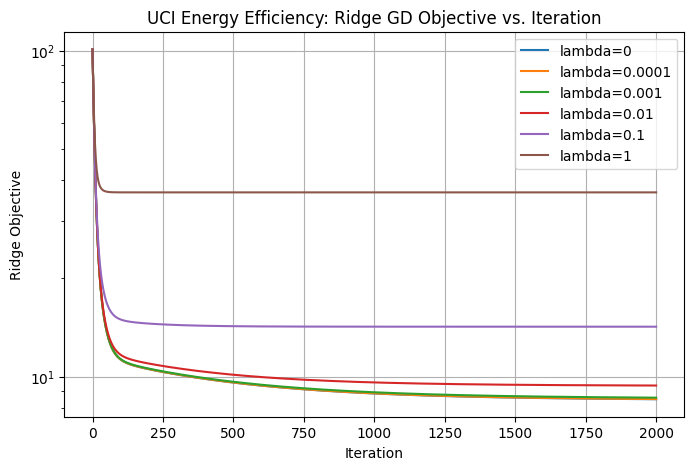

In [27]:
# Plot Convergence Behavior using Ridge GD
lambda_vals = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1]
learning_rate = 0.01

plt.figure(figsize=(8, 5))

for lambda_val in lambda_vals:
    weights, weight_history, loss_history, distance_history = gradient_descent_ridge(
        X_train,
        y_train,
        learning_rate=learning_rate,
        lambda_val=lambda_val,
        n_iterations=2000
    )

    plt.semilogy(loss_history, label=fr"lambda={lambda_val}")

plt.xlabel("Iteration")
plt.ylabel("Ridge Objective")
plt.title("UCI Energy Efficiency: Ridge GD Objective vs. Iteration")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Evaluating Test MSE
for lambda_val in lambda_vals:
    weights, _, _, _ = gradient_descent_ridge(X_train, y_train, learning_rate=learning_rate, lambda_val=lambda_val, n_iterations=2000)

    y_pred = X_test @ weights
    test_mse = np.mean((y_pred - y_test) ** 2)

    print(f"lambda={lambda_val:.0e}, test MSE={test_mse:.4f}")

lambda=0e+00, test MSE=9.4848
lambda=1e-04, test MSE=9.4868
lambda=1e-03, test MSE=9.5047
lambda=1e-02, test MSE=9.6999
lambda=1e-01, test MSE=11.4280
lambda=1e+00, test MSE=21.1319


In [29]:
# Ridge conditioning
for lambda_val in lambda_vals:
    H = (X_train.T @ X_train) / X_train.shape[0] + lambda_val * np.eye(X_train.shape[1])
    print(f"lambda={lambda_val:.0e}, cond={np.linalg.cond(H):.2e}")

lambda=0e+00, cond=2.88e+15
lambda=1e-04, cond=3.71e+04
lambda=1e-03, cond=3.71e+03
lambda=1e-02, cond=3.72e+02
lambda=1e-01, cond=3.81e+01
lambda=1e+00, cond=4.71e+00


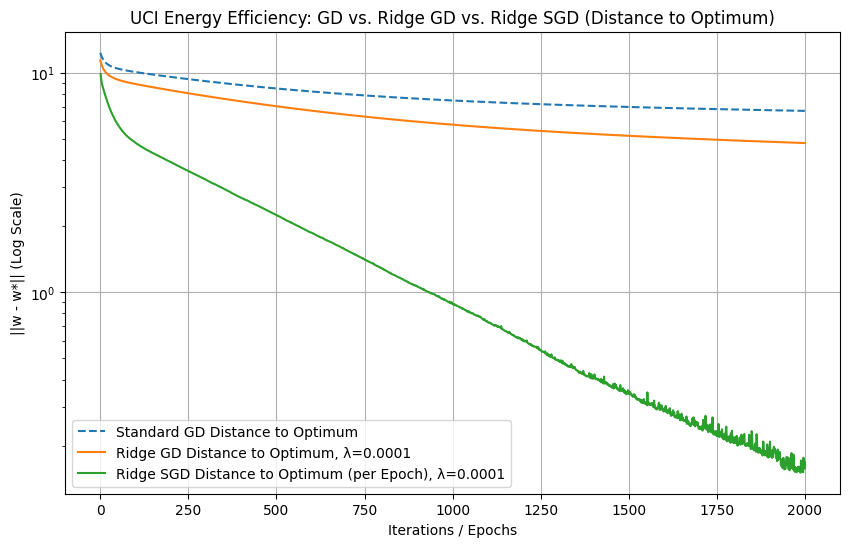

In [30]:
# Re-run the optimization to capture distance to optimum histories
lambda_val_comparison = 1e-4
n_iterations_gd = 2000
n_epochs_sgd = 2000

# Standard GD: lambda = 0
_, _, loss_std, distance_std = gradient_descent_ridge(
    X_train, y_train,
    learning_rate=0.01,
    lambda_val=0,
    n_iterations=n_iterations_gd
)

# Ridge GD
_, _, loss_gd, distance_gd = gradient_descent_ridge(
    X_train, y_train,
    learning_rate=0.01,
    lambda_val=lambda_val_comparison,
    n_iterations=n_iterations_gd
)

# Ridge SGD (using ridge_sgd_with_history for full weight history)
_, weight_history_sgd_real, loss_sgd = ridge_sgd(
    X_train, y_train,
    learning_rate=0.01,
    lambda_val=lambda_val_comparison,
    n_epochs=n_epochs_sgd,
    batch_size=32
)

# Calculate optimal weights for comparison
w_star_std = ridge_closed_form_solution(X_train, y_train, 0) # OLS solution
w_star_ridge = ridge_closed_form_solution(X_train, y_train, lambda_val_comparison)

# Recalculate distance to optimum for SGD with the actual w_star_ridge
distance_sgd_real = [np.linalg.norm(w - w_star_ridge) for w in weight_history_sgd_real]

plt.figure(figsize=(10, 6))

plt.semilogy(distance_std, label='Standard GD Distance to Optimum', linestyle='--')
plt.semilogy(distance_gd, label=f'Ridge GD Distance to Optimum, λ={lambda_val_comparison}')

# Plot SGD Distance to Optimum, aligning per epoch
updates_per_epoch_real = int(np.ceil(X_train.shape[0] / 32)) # Assuming batch_size=32
sgd_epochs_x_axis_real = np.arange(1, n_epochs_sgd + 1)
sgd_distances_at_epoch_end_real = [distance_sgd_real[i * updates_per_epoch_real] for i in sgd_epochs_x_axis_real]
plt.semilogy(sgd_epochs_x_axis_real, sgd_distances_at_epoch_end_real, label=f'Ridge SGD Distance to Optimum (per Epoch), λ={lambda_val_comparison}')

plt.xlabel("Iterations / Epochs")
plt.ylabel("||w - w*|| (Log Scale)")
plt.title("UCI Energy Efficiency: GD vs. Ridge GD vs. Ridge SGD (Distance to Optimum)")
plt.legend()
plt.grid(True)
plt.show()

## 6. Theoretical vs. Empirical Convergence Rate Discussion

In [31]:
# Theoretical convergence rate:

To compare the empirical convergence rates with the theoretical predictions, we first define a helper function to calculate the theoretical convergence factor 'c' for Gradient Descent (GD) and Ridge GD.

For a strongly convex function, the theoretical rate of convergence for GD is given by:

$$ ||w^{(t)} - w^*|| \le \left(\frac{\kappa - 1}{\kappa + 1}\right)^t ||w^{(0)} - w^*|| $$
where $\kappa$ is the condition number of the Hessian of the objective function. When the learning rate is chosen optimally as $2 / (L + \mu)$, where $L$ and $\mu$ are the largest and smallest eigenvalues of the Hessian, respectively, the convergence factor is $\frac{L - \mu}{L + \mu}$.

For a general learning rate, the convergence factor $c$ can be approximated as $max(|1 - \alpha L|, |1 - \alpha \mu|)$, where $\alpha$ is the learning rate.

In [32]:
# Helper function to calculate theoretical convergence factor 'c' for GD/Ridge GD
def theoretical_convergence_factor(X, lambda_val, learning_rate):
    n_samples, n_features = X.shape
    # Hessian for Ridge Regression objective: (2/n)X^T X + 2*lambda*I
    H = (2 / n_samples) * (X.T @ X) + 2 * lambda_val * np.eye(n_features)

    # Eigenvalues of the Hessian
    eigenvalues = np.linalg.eigvalsh(H)
    L = eigenvalues.max()  # Largest eigenvalue (Lipschitz constant)
    mu = eigenvalues.min() # Smallest eigenvalue

    # The actual convergence factor for a given learning rate
    c = max(abs(1 - learning_rate * L), abs(1 - learning_rate * mu))
    return c


# --- Calculate Theoretical Slopes

# Standard GD (OLS) - where lambda_val = 0
c_ols_theoretical = theoretical_convergence_factor(X_train, 0, learning_rate=0.01)
theoretical_slope_ols = np.log(c_ols_theoretical)
print(f"Theoretical Convergence Factor (OLS): {c_ols_theoretical:.4f}, Slope: {theoretical_slope_ols:.4f}")

# Ridge GD - using lambda_val_comparison
c_ridge_theoretical = theoretical_convergence_factor(X_train, lambda_val_comparison, learning_rate=0.01)
theoretical_slope_ridge = np.log(c_ridge_theoretical)
print(f"Theoretical Convergence Factor (Ridge GD): {c_ridge_theoretical:.4f}, Slope: {theoretical_slope_ridge:.4f}")


# --- Calculate Empirical Slopes

# Standard GD (OLS)
# Exclude initial zero distance if any, as log(0) is undefined
log_distance_std = np.log(np.array(distance_std[1:]))
iterations_std = np.arange(1, len(distance_std))
# Fit a linear model to log-distance vs. iterations to get the empirical slope
empirical_slope_std, empirical_intercept_std = np.polyfit(iterations_std, log_distance_std, 1)
print(f"Empirical Slope (Standard GD): {empirical_slope_std:.4f}")

# Ridge GD
log_distance_gd = np.log(np.array(distance_gd[1:]))
iterations_gd = np.arange(1, len(distance_gd))
empirical_slope_gd, empirical_intercept_gd = np.polyfit(iterations_gd, log_distance_gd, 1)
print(f"Empirical Slope (Ridge GD): {empirical_slope_gd:.4f}")

# Ridge SGD (plotting against total mini-batch updates)
# Total number of mini-batch updates is len(distance_sgd_real) - 1 (initial weight is before any update).
# Each iteration in `distance_sgd_real` represents one mini-batch update.
log_distance_sgd_real = np.log(np.array(distance_sgd_real[1:]))
iterations_sgd_real = np.arange(1, len(distance_sgd_real))
empirical_slope_sgd, empirical_intercept_sgd = np.polyfit(iterations_sgd_real, log_distance_sgd_real, 1)
print(f"Empirical Slope (Ridge SGD): {empirical_slope_sgd:.4f}")

# Calculate empirical slope for SGD per epoch
# First, create an x-axis for epochs for SGD
updates_per_epoch = int(np.ceil(X_train.shape[0] / 32)) # Assuming batch_size=32
sgd_epochs_x_axis = np.arange(1, n_epochs_sgd + 1)

# Get log distances corresponding to the end of each epoch
# The `distance_sgd_real` list contains distance after each mini-batch update.
# We need to sample this list at intervals corresponding to the number of updates per epoch.
log_distance_sgd_per_epoch = []
for epoch_idx in sgd_epochs_x_axis:
    # The index in `distance_sgd_real` for the end of an epoch is `epoch_idx * updates_per_epoch - 1`
    # We need to make sure we don't go out of bounds and that the index is positive
    list_idx = (epoch_idx * updates_per_epoch) -1 # Adjust for 0-indexing
    if list_idx < len(log_distance_sgd_real):
        log_distance_sgd_per_epoch.append(log_distance_sgd_real[list_idx])
    else:
        break

# Ensure there are enough points for fitting
if len(sgd_epochs_x_axis[:len(log_distance_sgd_per_epoch)]) > 1:
    empirical_slope_sgd_per_epoch, empirical_intercept_sgd_per_epoch = np.polyfit(sgd_epochs_x_axis[:len(log_distance_sgd_per_epoch)], log_distance_sgd_per_epoch, 1)
    print(f"Empirical Slope (Ridge SGD per Epoch): {empirical_slope_sgd_per_epoch:.4f}")
else:
    print("Not enough data points to calculate empirical slope for Ridge SGD per Epoch.")

Theoretical Convergence Factor (OLS): 1.0000, Slope: 0.0000
Theoretical Convergence Factor (Ridge GD): 1.0000, Slope: -0.0000
Empirical Slope (Standard GD): -0.0002
Empirical Slope (Ridge GD): -0.0003
Empirical Slope (Ridge SGD): -0.0001
Empirical Slope (Ridge SGD per Epoch): -0.0019


We can visualize the theoretical and empirical convergence rates. The plots below show the log of the distance to the optimum ($\log(||w - w^*||)$) against the number of iterations. A linear decrease in this log-distance indicates exponential convergence, and the slope of this line is related to the logarithm of the convergence factor. The theoretical lines represent the expected fastest possible convergence given the problem's conditioning and learning rate.

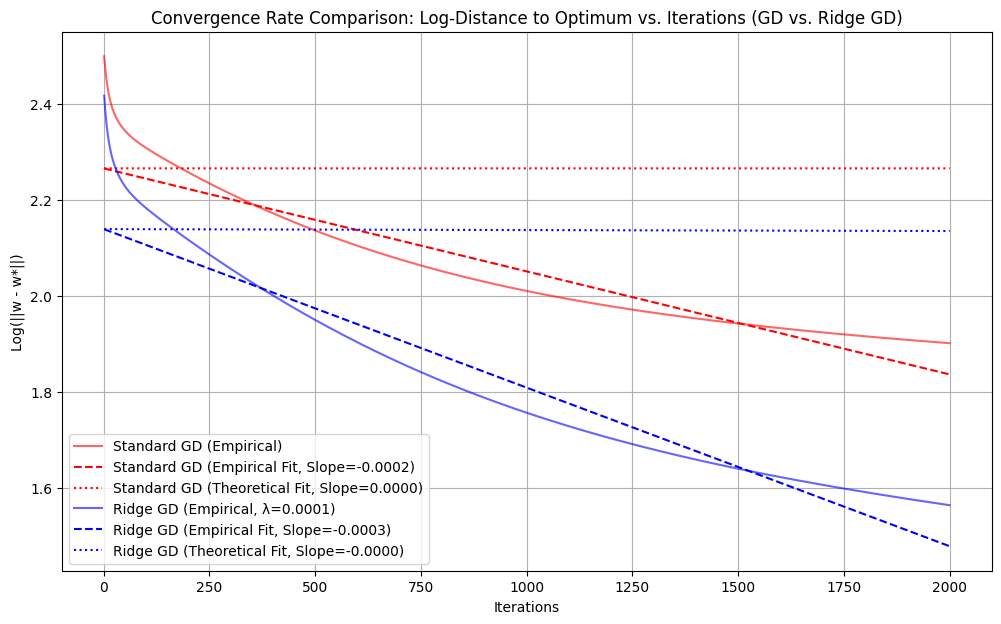

In [33]:
plt.figure(figsize=(12, 7))

# Plot Standard GD
plt.plot(iterations_std, log_distance_std, label='Standard GD (Empirical)', color='red', alpha=0.6)
plt.plot(iterations_std, empirical_slope_std * iterations_std + empirical_intercept_std, '--', color='red', label=f'Standard GD (Empirical Fit, Slope={empirical_slope_std:.4f})')
plt.plot(iterations_std, theoretical_slope_ols * iterations_std + empirical_intercept_std, ':', color='red', label=f'Standard GD (Theoretical Fit, Slope={theoretical_slope_ols:.4f})')

# Plot Ridge GD
plt.plot(iterations_gd, log_distance_gd, label=f'Ridge GD (Empirical, λ={lambda_val_comparison})', color='blue', alpha=0.6)
plt.plot(iterations_gd, empirical_slope_gd * iterations_gd + empirical_intercept_gd, '--', color='blue', label=f'Ridge GD (Empirical Fit, Slope={empirical_slope_gd:.4f})')
plt.plot(iterations_gd, theoretical_slope_ridge * iterations_gd + empirical_intercept_gd, ':', color='blue', label=f'Ridge GD (Theoretical Fit, Slope={theoretical_slope_ridge:.4f})')

plt.xlabel('Iterations')
plt.ylabel('Log(||w - w*||)')
plt.title('Convergence Rate Comparison: Log-Distance to Optimum vs. Iterations (GD vs. Ridge GD)')
plt.legend()
plt.grid(True)
plt.show()

The Ridge SGD plot shows its convergence behavior. While SGD often converges faster than GD in terms of epochs (due to more frequent updates), its convergence might be noisier due to the stochastic nature of its gradients.

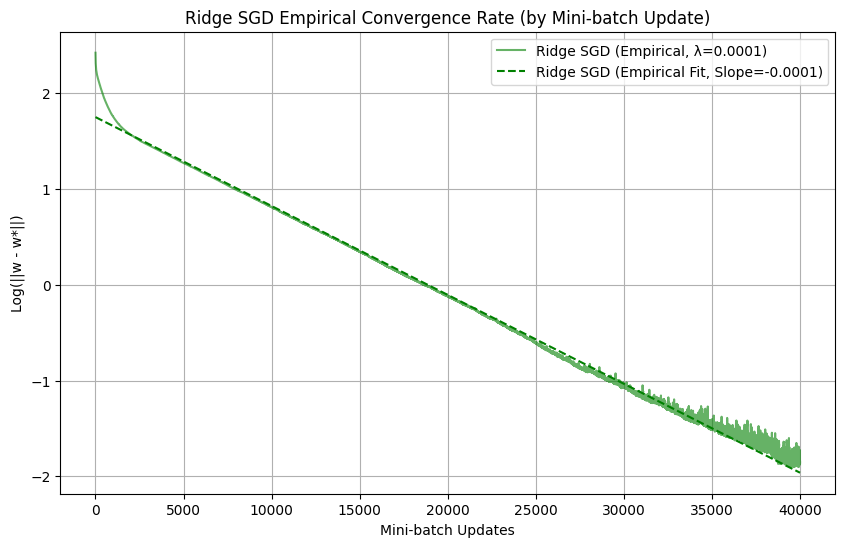

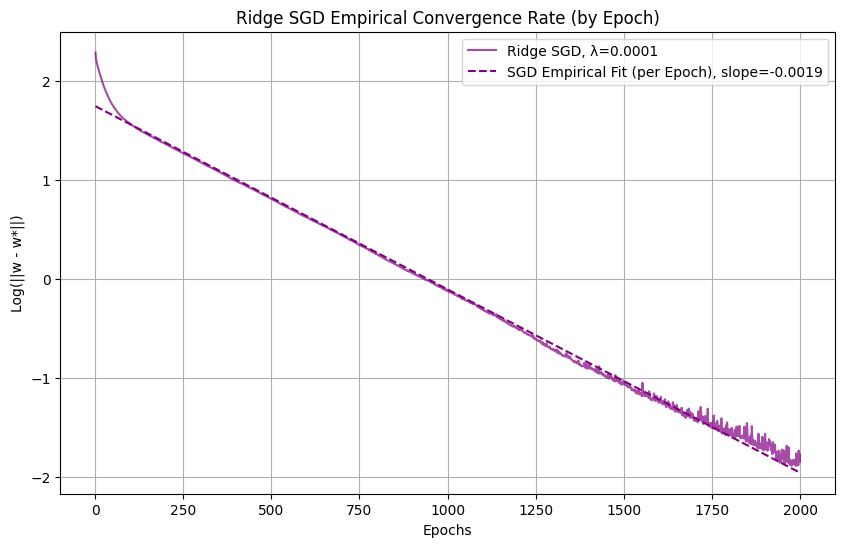

In [34]:
plt.figure(figsize=(10,6))

# Plot SGD, using the full sequence of mini-batch updates
plt.plot(iterations_sgd_real, log_distance_sgd_real, label=f'Ridge SGD (Empirical, λ={lambda_val_comparison})', color='green', alpha=0.6)
plt.plot(iterations_sgd_real, empirical_slope_sgd * iterations_sgd_real + empirical_intercept_sgd, '--', color='green', label=f'Ridge SGD (Empirical Fit, Slope={empirical_slope_sgd:.4f})')

plt.xlabel('Mini-batch Updates')
plt.ylabel('Log(||w - w*||)')
plt.title('Ridge SGD Empirical Convergence Rate (by Mini-batch Update)')
plt.legend()
plt.grid(True)
plt.show()

# Plot SGD, aligning per epoch
plt.figure(figsize=(10,6))
plt.plot(sgd_epochs_x_axis[:len(log_distance_sgd_per_epoch)], log_distance_sgd_per_epoch,
         label=f'Ridge SGD, λ={lambda_val_comparison}', color='purple', alpha=0.7)


if 'empirical_slope_sgd_per_epoch' in locals():
    plt.plot(sgd_epochs_x_axis[:len(log_distance_sgd_per_epoch)],
             empirical_slope_sgd_per_epoch * sgd_epochs_x_axis[:len(log_distance_sgd_per_epoch)] + empirical_intercept_sgd_per_epoch,
             '--', color='purple',
             label=f'SGD Empirical Fit (per Epoch), slope={empirical_slope_sgd_per_epoch:.4f}')

plt.xlabel("Epochs")
plt.ylabel("Log(||w - w*||)")
plt.title("Ridge SGD Empirical Convergence Rate (by Epoch)")
plt.legend()
plt.grid(True)
plt.show()